Задание 2. Используя набор данных на листе «Training» (см. Задания_1_2.xlsx)   в качестве обучающей выборки, предсказать значения целевой переменной Target для набора данных на листе «Validate».  Пояснить выбор метода. Привести оценки точности и качества предиктивной модели. Построить ROC-кривую. Назвать три наиболее важных предиктора.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sps
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
path = "З†§†≠®п_1_2.xlsx"
exel_file = pd.ExcelFile(path)
print("names of lists", exel_file.sheet_names)

names of lists ['Timeseries', 'Training', 'Validate']


In [3]:
df = pd.read_excel(
    path,
    sheet_name="Training"
)
validate_df = pd.read_excel(
    path,
    sheet_name="Validate"
)
df.head()

,ID,Target,P1,P2,P3,P4,P5,P6,P7,P8,...,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31
0,283,1,0.0,NaN,NaN,10,0,1.02273,1.01608,1.55268,...,831.68333,783.81667,171.33333,818.15000,0.62772,0.13333,0.00000,6.41893,0.97122,6.41893
1,342,0,0.0,30.00000,6.80153,0,0,1.00000,1.65348,1.14852,...,195.13889,168.30000,81.00000,NaN,6.32407,0.26667,0.33333,NaN,1.60714,3.44800
2,631,0,0.0,30.00000,9.60267,0,0,1.00000,0.84143,NaN,...,226.10556,207.41667,110.00000,184.49444,2.25635,0.00000,0.06667,NaN,0.75000,8.08000
3,1165,0,0.0,30.33333,15.32553,0,0,0.98901,0.88114,NaN,...,567.53889,441.52778,194.00000,625.32222,2.74469,0.13333,0.40000,13.50400,0.98119,13.50400
4,1469,0,0.0,28.00000,7.54133,0,0,0.92857,1.21447,0.60138,...,154.80556,86.64444,71.66667,53.45000,0.91130,0.46667,0.40000,NaN,0.40171,3.44800


Посмотрим пропуски на данных. 

In [4]:
pd.DataFrame(df.isna().sum()[df.isna().sum() != 0],
    index=df.columns[df.isna().sum() != 0])

,0
P2,1508
P3,1477
P8,1518
P16,1525
P25,1504
P29,1533


In [5]:
pd.DataFrame(validate_df.isna().sum()[validate_df.isna().sum() != 0],
    index=validate_df.columns[validate_df.isna().sum() != 0])

,0
Target,20000
P2,2968
P3,2979
P8,3015
P16,3003
P25,3021
P29,3013


Как видно, пропуски есть на одинаковых столбцах в train и valid. Значить можно писать ColumnTransformer только лишь для этих признаков.

In [6]:
df["Target"].mean()

np.float64(0.5)

Дисбаланса классов нет, поэтому можно делать split без проблем с дисбалансом классов.

Сначала сравним несколько типов моделей эмпирически на одинаковой кросс-валидации. 
1. Logistic Lasso
2. Random Forest
3. Gradient Boosting

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

nan_columns = ["P2", "P3", "P8", "P16", "P25", "P29"]

model = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median",
                       add_indicator=True
        )
    ),
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            l1_ratio=0.5,
            solver="saga",
            C=10,
            max_iter=2000,
            random_state=42
        )
    )
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possibl

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["ID", "Target"]),
    df["Target"],
    test_size=0.2,
    stratify=df["Target"],
    random_state=42   
)

fitted_model = model.fit(X_train, y_train)
y_probability = fitted_model.predict_proba(X_test)[:, 1]

/Users/stiv/Desktop/AnalystCaces/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [38]:
from sklearn.metrics import roc_auc_score, accuracy_score

y_pred = fitted_model.predict(X_test)

print("accuracy_score: ", accuracy_score(y_test, y_pred))

accuracy_score:  0.7


In [67]:
from catboost import CatBoostClassifier

model_boost = CatBoostClassifier(
            iterations=10000,
            learning_rate=0.01,
            depth=8,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            verbose=False
        )
fitted_boost = model_boost.fit(X=X_train, y=y_train)
preds_boost = fitted_boost.predict_proba(X_test)[:, 1]

In [80]:
from sklearn.ensemble import RandomForestClassifier

model_forest = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=10000,
            criterion="log_loss",
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )
    )
])

fitted_forest = model_forest.fit(X=X_train, y=y_train)
preds_forest = fitted_forest.predict_proba(X=X_test)[:, 1]

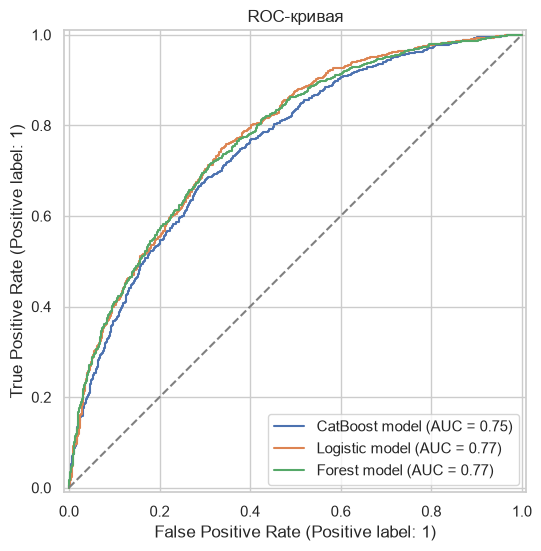

In [81]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 6))

RocCurveDisplay.from_predictions(
    y_test,
    preds_boost,
    ax=ax,
    name="CatBoost model"
)
RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    name="Logistic model",
    ax=ax
)
RocCurveDisplay.from_predictions(
    y_test,
    preds_forest,
    name="Forest model",
    ax=ax
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)
plt.legend()
plt.title("ROC-кривая")

plt.show()

Были сопоставлены логистическая регрессия с регуляризацией, Random Forest и CatBoost. Логистическая регрессия и Random Forest продемонстрировали сопоставимое качество, тогда как CatBoost не дал улучшения. В качестве итоговой выбрана логистическая модель благодаря сопоставимому ROC-AUC, меньшей сложности и непосредственной интерпретируемости коэффициентов.

Следующим этапом будет доработка линейной регрессии.
Будем оценивать уже не только по ROC-AUC, а по нескольким оценкам
- `Accuracy` – доля правильных ответов;
- `Precision` – точность предсказания класса 1
- `Recall` – какую долю настоящих единиц обнаружили
- `F1-score` – баданс между Precision и Recall
- `ROC-AUC`
- средний ROC-AUC по кросс валидации